In [1]:
# Importing essential libraries for data analysis and visualization
import pandas as pd          # PANDAS: Data manipulation and analysis library (2008, Wes McKinney)
import numpy as np           # NUMPY: Handles large multidimensional arrays/matrices efficiently
import matplotlib.pyplot as plt  # MATPLOTLIB: Base Python visualization library (like MATLAB)
import seaborn as sns        # SEABORN: Built on matplotlib, offers advanced statistical plots
# for inline display of plots in Jupyter Notebook
%matplotlib inline  

In [79]:
''' Load and describe the Adult Income Census dataset
a. Source: 1994 Census database (via UCI ML Repository or Kaggle)
b. Number of rows and columns
c. Objective: Predict whether a person earns over $50K annually'''

# Read the dataset (already present in your directory)
df = pd.read_csv('adult.csv')  # dataset includes demographic and income-related features

# Display basic shape information
print("Dataset Source: 1994 Census database (UCI ML Repository / Kaggle cleaned version)")
print(f"Number of Rows: {df.shape[0]}")  # total records
print(f"Number of Columns: {df.shape[1]}")  # total features

# Dataset objective
print("Objective: Predict whether a person earns more than $50K per year based on demographic features.")


Dataset Source: 1994 Census database (UCI ML Repository / Kaggle cleaned version)
Number of Rows: 32561
Number of Columns: 15
Objective: Predict whether a person earns more than $50K per year based on demographic features.


In [80]:
# ------------------- 3a. Display First and Last 5 Rows -------------------

# Displaying the first 5 rows of the dataset
df.head()  # Shows initial entries to understand the structure

# Displaying the last 5 rows of the dataset
df.tail()  # Useful to confirm consistency and spot tail-end anomalies

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32560,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [81]:
# ------------ 3b. Check for Missing Values in Each Column ---------
# Replace any string that is '?' with np.nan
df = df.replace('?', np.nan)

# Checking how many missing values exist in each column
df.isnull().sum() # Essential to identify columns requiring cleaning or imputation

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64

In [82]:
# -------3c. Summary Statistics, Shape, Dtypes, Nulls --------

# Displaying dataset shape: (rows, columns)
print(df.shape)  # Essential to understand dataset size

# Checking data types for each column (object, int, float)
print(df.dtypes)  # Helps decide encoding/scaling methods

# Display summary statistics for numerical features
print(df.describe())  # Includes count, mean, std dev, min, max

# Display full summary including categorical columns
print(df.describe(include='all'))  # For both numeric and object-type columns

# Checking null values after replacing '?' with NaN
print(df.isnull().sum())  # Reinforces which features need imputation

#checking the actual column names 
df.columns

(32561, 15)
age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object
                age        fnlwgt  education.num  capital.gain  capital.loss  \
count  32561.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.581647  1.897784e+05      10.080679   1077.648844     87.303830   
std       13.640433  1.055500e+05       2.572720   7385.292085    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.370510e+05      

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='object')

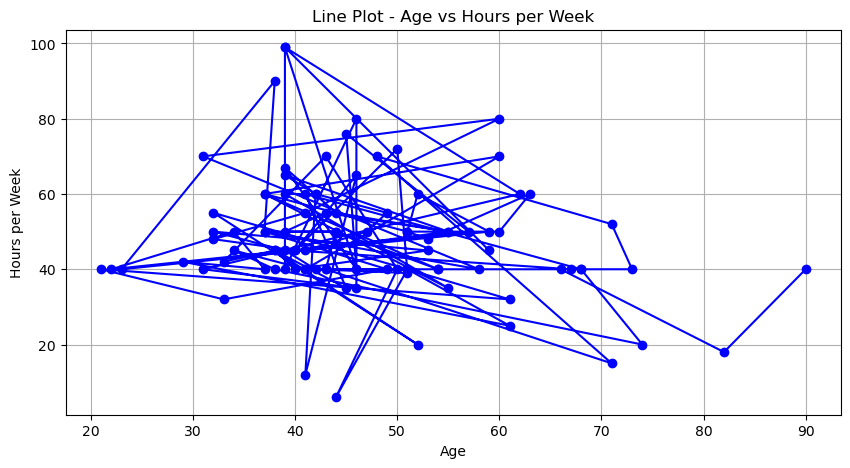

In [83]:
# -------3d. Visualize the dataset using charts --------

# (i)Line Plot: Age vs Hours per Week (line chart to observe trend)
plt.figure(figsize=(10,5))  # setting figure size
plt.plot(df['age'][:100], df['hours.per.week'][:100], color='blue', marker='o')  # line plot for 100 samples
plt.title("Line Plot - Age vs Hours per Week")  # chart title
plt.xlabel("Age")  # x-axis label
plt.ylabel("Hours per Week")  # y-axis label
plt.grid(True)  # grid lines for better readability
plt.show()

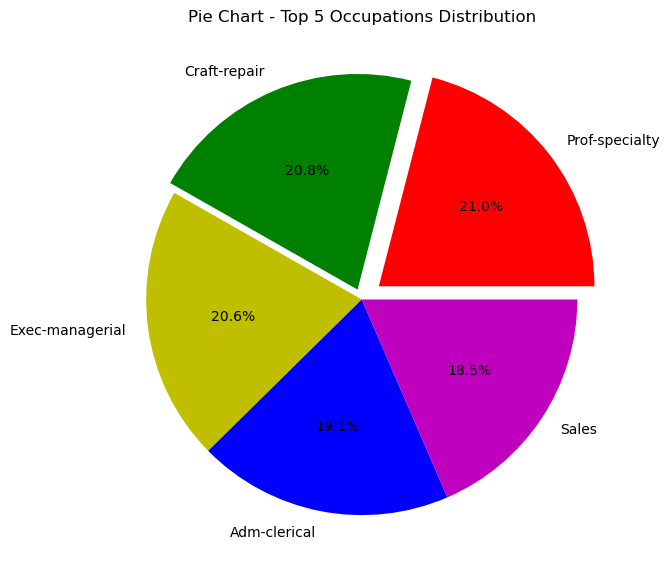

In [84]:
# (ii)Pie Chart showing distribution of top occupations
# Shows percentage of people in top 5 job types
top_occupations = df['occupation'].value_counts().nlargest(5)  # top 5 frequent occupations
plt.figure(figsize=(7,7))  # square shape for pie chart
plt.pie(top_occupations, labels=top_occupations.index, autopct='%1.1f%%', explode = [0.1, 0.05, 0, 0, 0], colors=['r','g','y','b','m'])  # pie with custom colors
plt.title("Pie Chart - Top 5 Occupations Distribution")  # plot title
plt.show()  # render chart


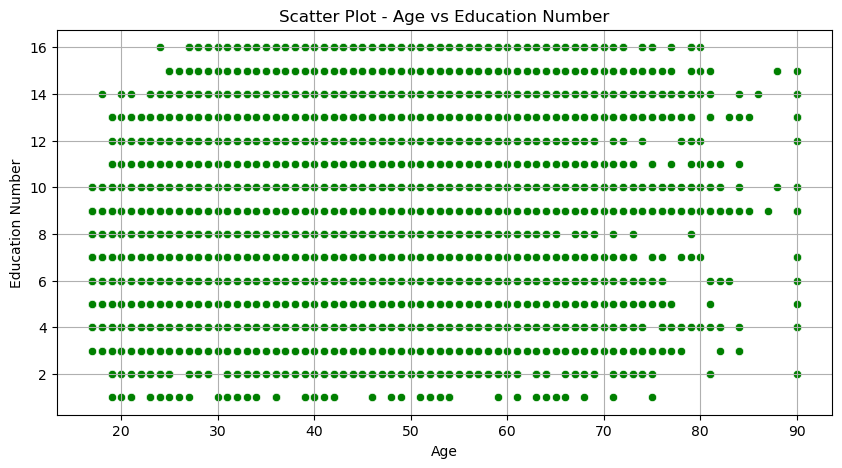

In [85]:
#  (iii)Scatter Plot – Visualizes the relationship between age and numeric education level
plt.figure(figsize=(10, 5))  # set the figure size to 10x5
sns.scatterplot(x='age', y='education.num', data=df, color='green')  # scatter plot of age vs education-num
plt.title("Scatter Plot - Age vs Education Number")  # add plot title
plt.xlabel("Age")  # label x-axis
plt.ylabel("Education Number")  # label y-axis
plt.grid(True)  # enable grid for better readability
plt.show()  # display the plot


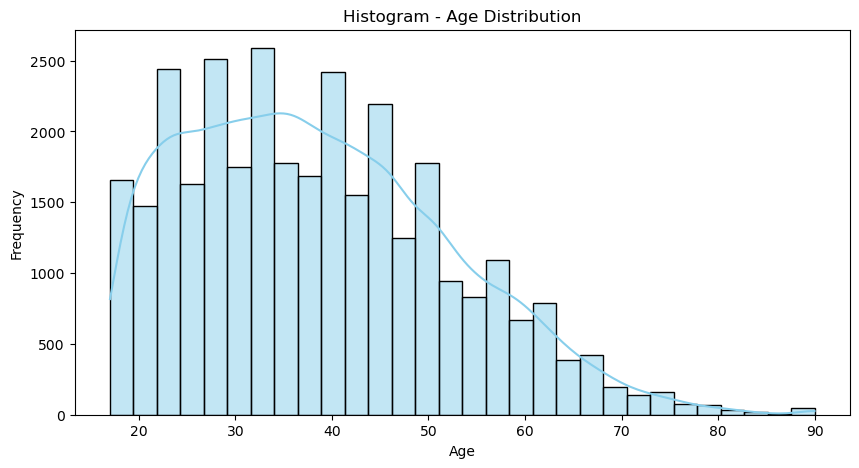

In [86]:
# (iv) Histogram: Frequency distribution of age
# Shows the shape and spread of the age variable
plt.figure(figsize=(10,5))
sns.histplot(df['age'], kde=True, bins=30, color='skyblue')  # histogram + KDE curve 
# KDE (Kernel Density Estimation) - Smooth curve showing data distribution
plt.title("Histogram - Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

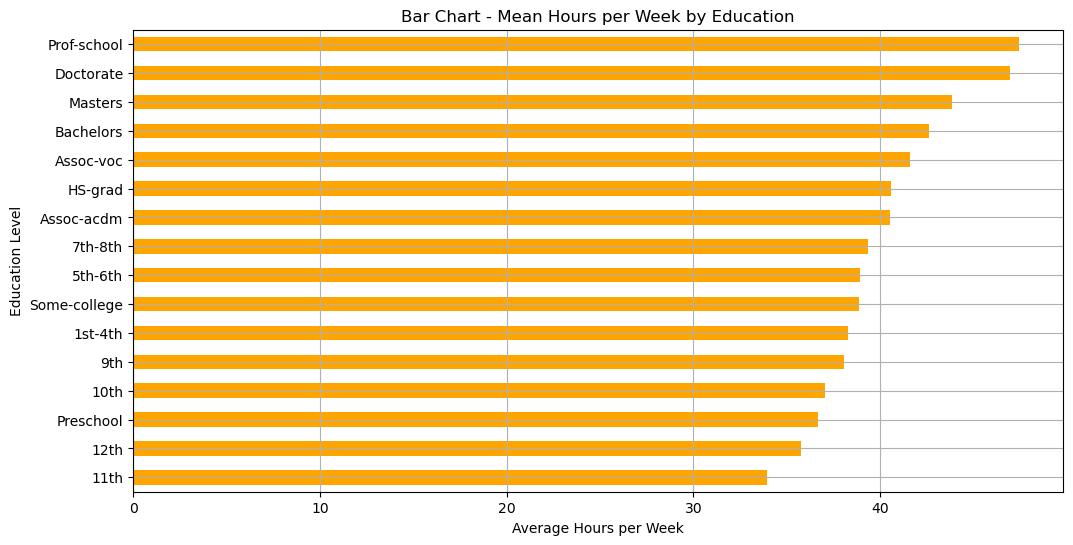

In [87]:
# (v)Bar Chart: Average working hours per education level
# Allows comparison of education vs average work time
edu_hours = df.groupby('education')['hours.per.week'].mean().sort_values()  # group by education
plt.figure(figsize=(12,6))
edu_hours.plot(kind='barh', color='orange')  # horizontal bar chart
plt.title("Bar Chart - Mean Hours per Week by Education")
plt.xlabel("Average Hours per Week")
plt.ylabel("Education Level")
plt.grid(True)
plt.show()


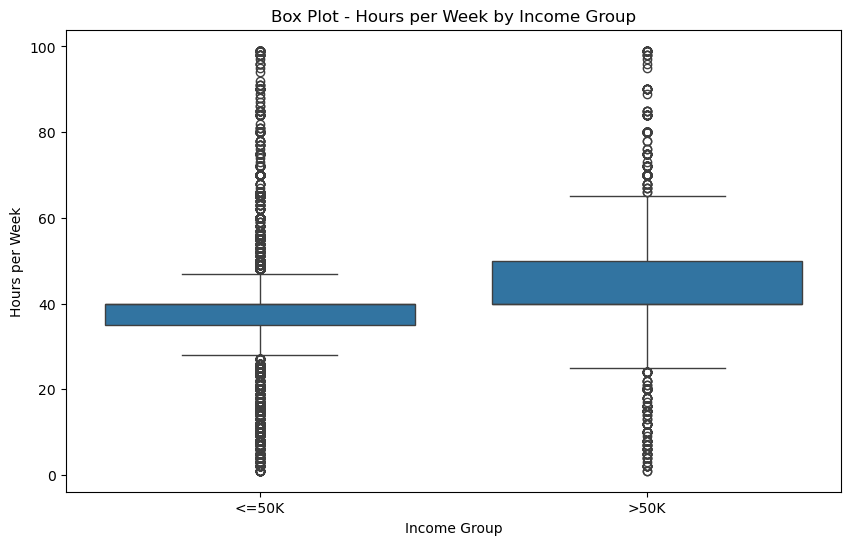

In [88]:
#(vi) Box Plot: Spread of working hours grouped by income class
# Shows median, quartiles, and outliers
plt.figure(figsize=(10,6))
sns.boxplot(x='income', y='hours.per.week', data=df)  # boxplot for hours by income
plt.title("Box Plot - Hours per Week by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Hours per Week")
plt.show()


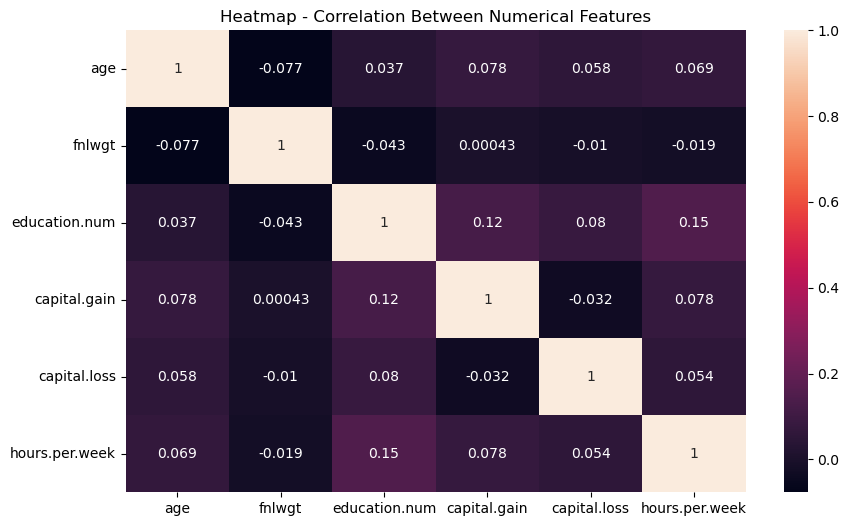

In [89]:
# (vii)Heatmap – Displays correlation between numeric variables
corr = df.corr(numeric_only=True)  # compute correlation between numeric columns
plt.figure(figsize=(10, 6))  # set figure size
sns.heatmap(corr, annot=True)  # heatmap with correlation values
plt.title("Heatmap - Correlation Between Numerical Features")  # title
plt.show()  # display chart

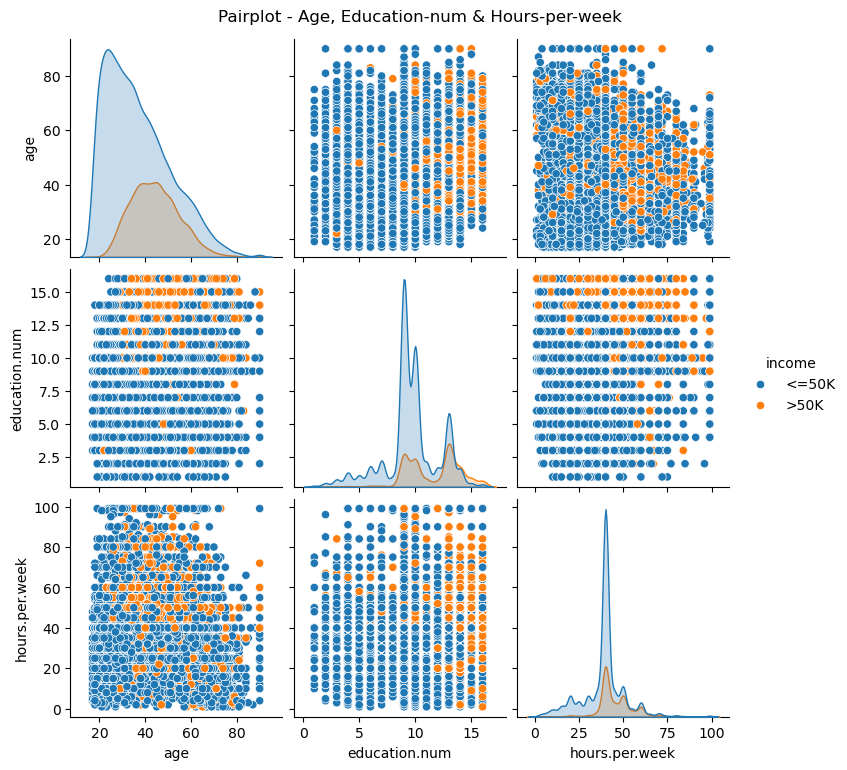

In [90]:
#(viii) Pairplot: Multi-variable comparison of key features with income
# Great for spotting clustering and trends
sns.pairplot(df[['age', 'education.num', 'hours.per.week', 'income']], hue='income')
plt.suptitle("Pairplot - Age, Education-num & Hours-per-week", y=1.02)
plt.show()


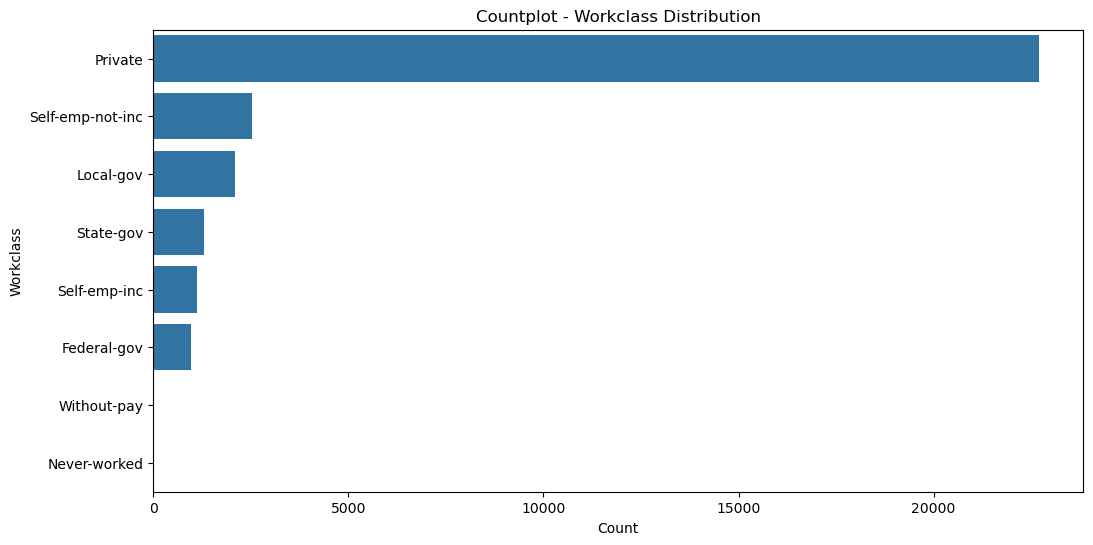

In [91]:
# (ix)Countplot: Frequency of each workclass category
# Helps understand employment type distribution
plt.figure(figsize=(12,6))
sns.countplot(y='workclass', data=df, order=df['workclass'].value_counts().index)  # sorted countplot
plt.title("Countplot - Workclass Distribution")
plt.xlabel("Count")
plt.ylabel("Workclass")
plt.show()


In [92]:
# -------4. Handle missing values --------

# Check missing values
print(df.isnull().sum())  # shows count of missing per column

# Drop rows where 'workclass' or 'occupation' is missing
df = df.dropna(subset=['workclass', 'occupation'])  # must assign back to df

# Drop 'native.country' column — 100% missing, no mode can be used
df = df.drop('native.country', axis=1)

# Confirm all missing values handled
print(df.isnull().sum())  # should all be 0

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64
age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
income            0
dtype: int64


In [93]:
# -------5(Feature Encoding) a. Identify the categorical columns. --------
# Feature Encoding: converting categorical data (text/labels) into numerical form
# Identify categorical columns automatically
cat_cols = df.select_dtypes(include='object').columns
print("Categorical Columns:", list(cat_cols))

Categorical Columns: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'income']


In [95]:
#-------5b Apply Label Encoding to binary/ordinal columns  --------
# Assigns an integer value to each category.
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Label Encoding for 'sex': binary (male/female), so label encoding is fine
df['sex'] = le.fit_transform(df['sex'])  # 0 = Female, 1 = Male

# Label Encoding for 'income' : binary (<=50K/>50K)
df['income'] = le.fit_transform(df['income'])  # 0 = <=50K, 1 = >50K

df[['sex', 'income']].head(2)  # Checking the result

,sex,income
1,0,0
3,0,0


In [117]:
#-------5b Apply One-Hot Encoding for nominal multi-category columns--------
# One-Hot Encoding avoids any false ordering of categorical levels
from sklearn.preprocessing import OneHotEncoder

# One-Hot Encoding avoids false ordering in multi-category columns
ohe = OneHotEncoder(drop='first', sparse_output=False)  # drop='first' avoids dummy variable trap

# Apply OHE on nominal categorical columns
encoded = ohe.fit_transform(df[nominal_cols])  # returns numpy array

# Create DataFrame from encoded result with new column names
df_ohe = pd.DataFrame(encoded, columns=ohe.get_feature_names_out(nominal_cols))

# Combine original data (without nominal columns) + encoded DataFrame
df_encoded = pd.concat([df.drop(columns=nominal_cols), df_ohe], axis=1)

# Display first few rows to confirm encoding
print(df_encoded.head(2))

# Show new shape after encoding (to see added columns)
print("Original shape:", df.shape)
print("Encoded shape :", df_encoded.shape)

    age    fnlwgt  education.num  sex  capital.gain  capital.loss  \
1  82.0  132870.0            9.0  0.0           0.0        4356.0   
3  54.0  140359.0            4.0  0.0           0.0        3900.0   

   hours.per.week  income workclass_Local-gov workclass_Private  ...  \
1            18.0     0.0               False              True  ...   
3            40.0     0.0               False              True  ...   

  occupation_Transport-moving relationship_Not-in-family  \
1                       False                       True   
3                       False                      False   

  relationship_Other-relative relationship_Own-child relationship_Unmarried  \
1                       False                  False                  False   
3                       False                  False                   True   

  relationship_Wife race_Asian-Pac-Islander race_Black race_Other race_White  
1             False                   False      False      False       True 

In [118]:
# -------6(Feature Scaling) a. Identify numerical columns-------
# Selecting only numeric columns
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
list(num_cols)

['age',
 'fnlwgt',
 'education.num',
 'capital.gain',
 'capital.loss',
 'hours.per.week']

In [119]:
# -------6b. Apply StandardScaler--------
# Standardizes features to have mean = 0 and std = 1
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()  # Create StandardScaler instance

# Scale selected numeric columns (example: 'age' and 'hours.per.week')
scaled_vals = sc.fit_transform(df[['age', 'hours.per.week']])

# Create DataFrame from scaled values
df_scaled = pd.DataFrame(scaled_vals, columns=['age', 'hours.per.week'])

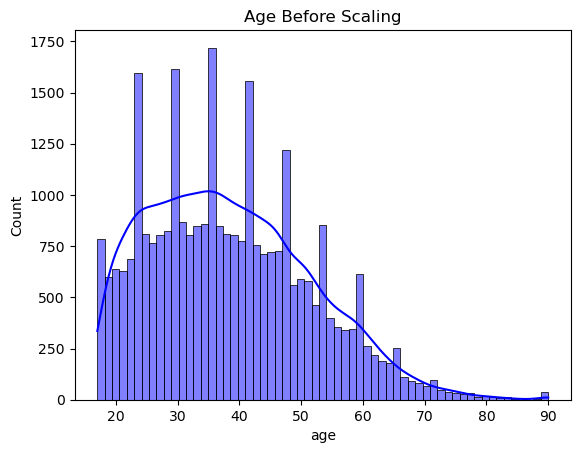

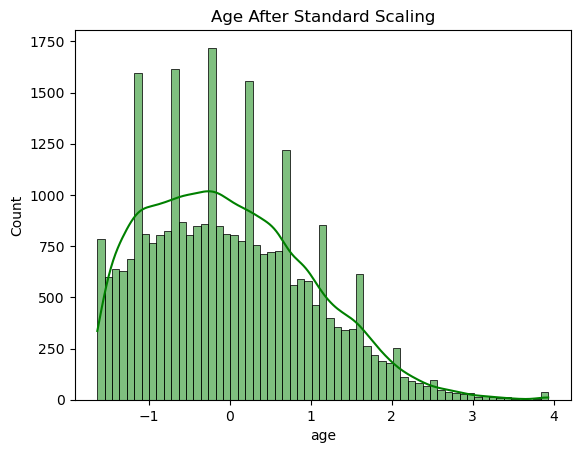

In [120]:
# -------6c. Visualize before and after scaling if possible.--------
import seaborn as sns
import matplotlib.pyplot as plt

# Before scaling
sns.histplot(df['age'], color='blue', kde=True)
plt.title("Age Before Scaling")
plt.show()

# After scaling
sns.histplot(df_scaled['age'], color='green', kde=True)
plt.title("Age After Standard Scaling")
plt.show()

In [121]:
# ---------------7a.Split Ratio: We'll use 80% for training and 20% for testing. ---------------
from sklearn.model_selection import train_test_split

# Assuming 'df_encoded' is your processed dataset
X = df_encoded.drop('income', axis=1)   # Independent features
y = df_encoded['income']                # Target variable

# Split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [122]:
# ---------------7b. Display the shape of the sets ---------------
print("Training Set:", X_train.shape, y_train.shape)
print("Testing Set:", X_test.shape, y_test.shape)

Training Set: (25944, 56) (25944,)
Testing Set: (6486, 56) (6486,)


In [126]:
'''--------8a. Algorithm Chosen: Random Forest Classifier------------
Justification:
Works well with both classification and regression.
Handles large datasets and high-dimensional features (like one-hot encoded ones).
Avoids overfitting better than decision trees.'''

'--------8a. Algorithm Chosen: Random Forest Classifier------------\nJustification:\nWorks well with both classification and regression./n\nHandles large datasets and high-dimensional features (like one-hot encoded ones).\nAvoids overfitting better than decision trees.'

In [131]:
#-------------8b. Train and display accuracy--------------
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Split data into features and target
X = df_encoded.drop('income', axis=1)  # features (processed)
y = df_encoded['income']               # target (already label encoded: 0 or 1)

# Handle missing target values if any
y = y.dropna()
X = X.loc[y.index]  # Align X with cleaned y

# Split dataset: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Initialize and train the model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Accuracy on test set
accuracy = rf.score(X_test, y_test)
print("Training Set:", X_train.shape, y_train.shape)
print("Testing Set:", X_test.shape, y_test.shape)
print("Accuracy Score:", accuracy)

Training Set: (24574, 56) (24574,)
Testing Set: (6144, 56) (6144,)
Accuracy Score: 0.85302734375


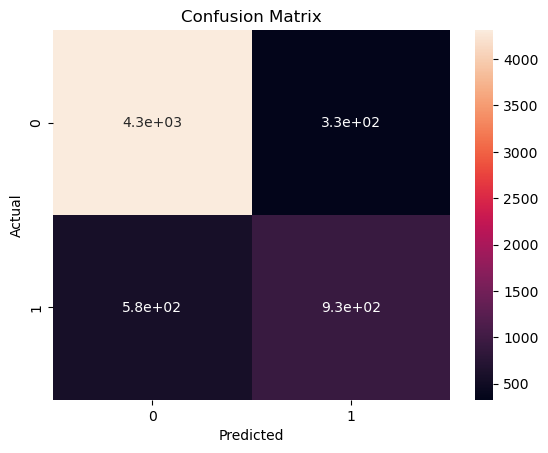

In [133]:
#-----------8c. Confusion Matrix-----------
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on test data
y_pred = rf.predict(X_test)

# Generate confusion matrix
conf_mat = confusion_matrix(y_test, y_pred)

# Plot simple heatmap
sns.heatmap(conf_mat, annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [134]:
#--------classification report-----------
from sklearn.metrics import classification_report

# Print classification metrics
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))


Classification Report:
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      4639
        >50K       0.74      0.62      0.67      1505

    accuracy                           0.85      6144
   macro avg       0.81      0.77      0.79      6144
weighted avg       0.85      0.85      0.85      6144



In [135]:
'''THANK YOU: 
SUBMITTED BY:TANYA SURATKAL'''

'THANK YOU: \nSUBMITTED BY:TANYA SURATKAL'